In [11]:
import altair as alt
import matplotlib.pyplot as plt
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from ml_homework.paths import RAW_DATA_DIR

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

data_path = RAW_DATA_DIR / "CC+GENERAL.csv"
# Read the CSV file into a DataFrame
df = pd.read_csv(data_path).head(2000)

# Display the first 5 rows
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))

# Print the column names and their data types
print(df.info())

| CUST_ID   | BALANCE   | BALANCE_FREQUENCY   | PURCHASES   | ONEOFF_PURCHASES   | INSTALLMENTS_PURCHASES   | CASH_ADVANCE   | PURCHASES_FREQUENCY   | ONEOFF_PURCHASES_FREQUENCY   | PURCHASES_INSTALLMENTS_FREQUENCY   | CASH_ADVANCE_FREQUENCY   | CASH_ADVANCE_TRX   | PURCHASES_TRX   | CREDIT_LIMIT   | PAYMENTS   | MINIMUM_PAYMENTS   | PRC_FULL_PAYMENT   | TENURE   |
|:----------|:----------|:--------------------|:------------|:-------------------|:-------------------------|:---------------|:----------------------|:-----------------------------|:-----------------------------------|:-------------------------|:-------------------|:----------------|:---------------|:-----------|:-------------------|:-------------------|:---------|
| C10001    | 40.9007   | 0.818182            | 95.4        | 0                  | 95.4                     | 0              | 0.166667              | 0                            | 0.083333                           | 0                        | 0                 


I'll start by preprocessing the data and then I'll use PCA to reduce the dimensions of the data to 2.

In [4]:
# Drop the column `CUST_ID`
df = df.drop("CUST_ID", axis=1)

# Drop rows with null values
df = df.dropna()

# Fit the PCA model with 2 components
pca = PCA(n_components=2)
principal_components = pca.fit_transform(StandardScaler().fit_transform(df))

# Display the principal components
pca_df = pd.DataFrame(data=principal_components, columns=["PC1", "PC2"])
print(pca_df.head().to_markdown(index=False, numalign="left", stralign="left"))

| PC1      | PC2       |
|:---------|:----------|
| -1.9244  | -1.20484  |
| -1.44677 | 1.78102   |
| 0.377469 | -0.819454 |
| -1.84506 | -0.870152 |
| -0.29743 | -0.839586 |



Now, I'll use the silhouette score to find the optimal number of clusters.

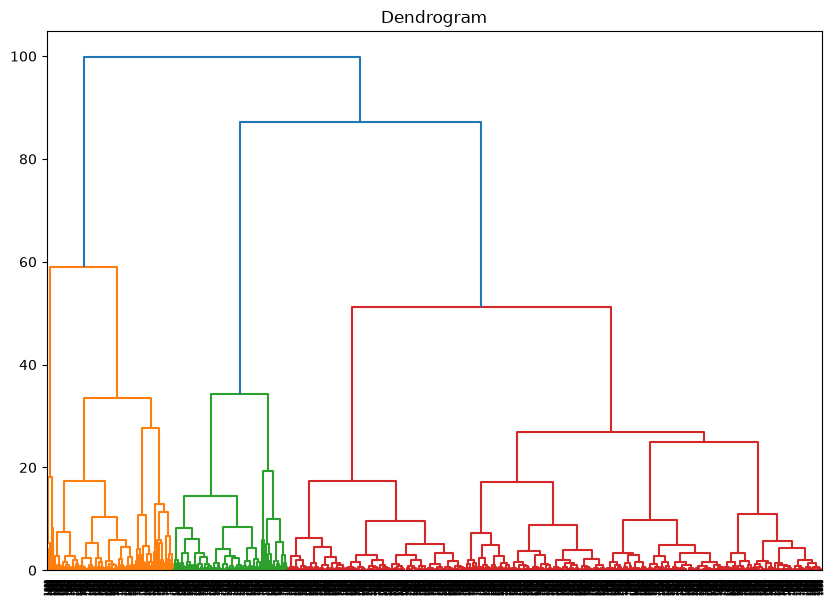

In [12]:
# Create the dendrogram
plt.figure(figsize=(10, 7))
plt.title("Dendrogram")
dend = dendrogram(linkage(pca_df, method="ward"))

# Save the dendrogram
plt.show()

In [6]:
# Initialize lists to store the number of clusters and their corresponding silhouette scores
n_clusters_list = []
silhouette_scores_list = []

# Loop through different numbers of clusters
for n_clusters in range(2, 11):
    # Fit the hierarchical clustering model
    clusterer = AgglomerativeClustering(n_clusters=n_clusters)
    cluster_labels = clusterer.fit_predict(principal_components)

    # Calculate the silhouette score
    silhouette_avg = silhouette_score(principal_components, cluster_labels)

    # Append the number of clusters and silhouette score to the lists
    n_clusters_list.append(n_clusters)
    silhouette_scores_list.append(silhouette_avg)

# Display the number of clusters with the highest silhouette score
print(
    f"Optimal number of clusters: {n_clusters_list[silhouette_scores_list.index(max(silhouette_scores_list))]}"
)

# Display the lists of number of clusters and silhouette scores
print(f"Number of clusters: {n_clusters_list}")
print(f"Silhouette scores: {silhouette_scores_list}")

Optimal number of clusters: 2
Number of clusters: [2, 3, 4, 5, 6, 7, 8, 9, 10]
Silhouette scores: [0.4359763337400389, 0.4306127501634657, 0.4250723710390432, 0.33301800442646, 0.31947917460328434, 0.32393769452781473, 0.33175152717815964, 0.30654450819214946, 0.323010992557681]



I'll visualize the clusters formed for 2 clusters as it has the highest silhouette score.

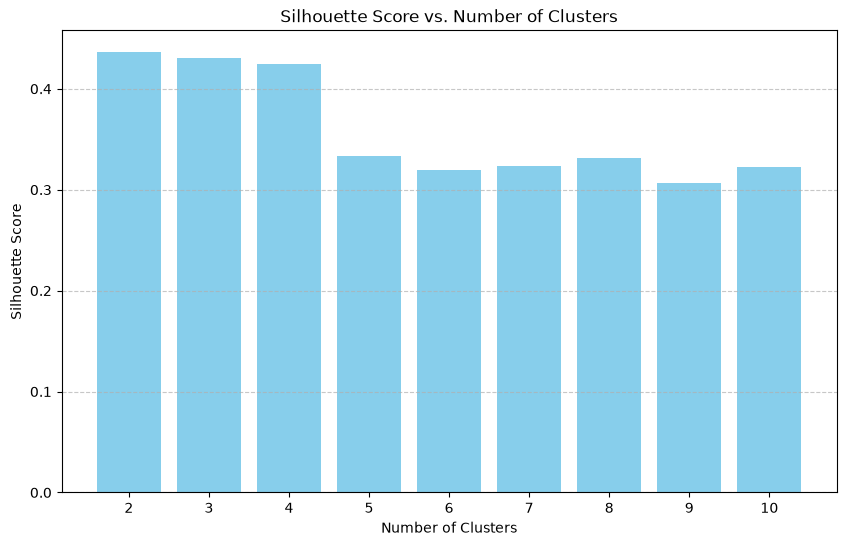

In [7]:
# prompt: create a barchart for silhouette_scores_list and n_clusters_list

# Create the bar chart
plt.figure(figsize=(10, 6))
plt.bar(n_clusters_list, silhouette_scores_list, color="skyblue")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs. Number of Clusters")
plt.xticks(n_clusters_list)  # Ensure all x-axis values are displayed
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [10]:
# Fit the hierarchical clustering model with 3 clusters
clusterer = AgglomerativeClustering(n_clusters=3)
cluster_labels = clusterer.fit_predict(principal_components)

# Add the cluster labels to the DataFrame
pca_df["Cluster"] = cluster_labels

# Create a scatter plot with PC1 on the x-axis and PC2 on the y-axis
chart = (
    alt.Chart(pca_df)
    .mark_point()
    .encode(x="PC1", y="PC2", color="Cluster:N", tooltip=["PC1", "PC2", "Cluster"])
    .properties(title="Hierarchical Clustering with 3 Clusters")
    .interactive()
)

# Save the chart
chart.save("hierarchical_clustering_scatter_plot.json")
chart

alt.Chart(...)


The optimal number of clusters is 2.

Here is a step-by-step guide to explaining hierarchical clustering to your students:

1. Start by preprocessing the data by removing the column `CUST_ID` as it is not relevant to our analysis and removing the rows with missing values.

2. Reduce the dimensions of the data using PCA.

3. Fit the data with `n_clusters` ranging from 2 to 10 to a hierarchical clustering model.

4. Calculate the silhouette score for each fitted model.

5. Display the number of clusters with the highest silhouette score.

6. Visualize the clusters formed.
